In [1]:
import numpy as np

import scarf

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)

Downloading bucket files: 40169307 / 40169307 complete

Downloading bytes: 40169307 / 40169307 complete

Downloading bucket files: 46151508 / 46151508 complete

Downloading bytes: 46151508 / 46151508 complete

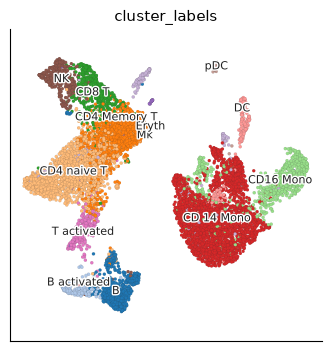

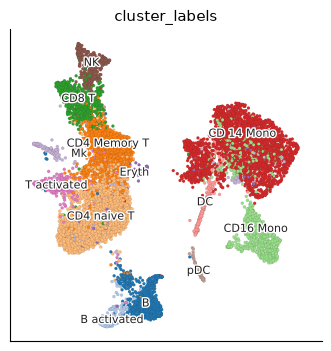

In [2]:
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)

In [3]:
labelled = ds_ctrl.cells.fetch_all("cluster_labels").astype(str) != "nan"
ds_ctrl.cells.insert(
    "annotated",
    ds_ctrl.cells.fetch_all("I").astype(bool) & labelled,
    overwrite=True,
)
print(
    "annotated reference cells:",
    int(ds_ctrl.cells.fetch_all("annotated").sum()),
)
ds_ctrl.mark_hvgs(
    cell_key="annotated",
    top_n=2000,
    min_cells=10,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)

annotated reference cells: 8486


Computing RNA feature statistics: 10 / 10 complete

In [4]:
normalized = ds_ctrl.run_normalization(cell_key="annotated", feat_key="hvgs")
pca = ds_ctrl.run_pca(normalized, dims=25, feat_scaling=True)
ann_index = ds_ctrl.build_ann_index(pca)
neighbors = ds_ctrl.query_neighbors(ann_index, k=17)
reference = ds_ctrl.build_mapping_reference(neighbors)
reference

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

MappingReference(datastore=DataStore has 8486 (8487) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'annotated', 'RNA_percentMito', 
            'RNA_clusters', 'cluster_labels', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_UMAP1', 'RNA_UMAP2'
   RNA assay has 10683 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs', 'annotated__hvgs', 'stats_annotated_normed_tot', 'stats_annotated_normed_n', 'stats_annotated_avg', 
            'stats_annotated_c_var__adaptive__200__0.1', 'stats_annotated_nz_mean', 'stats_annotated_sigmas', ref=ArtifactRef(assay='RNA', kind='mapping_reference', artifact_id='10a33175eb96...'), assay_name='RNA', cell_key='annotated', feature_key='hvgs', reduction=ArtifactRef(assay='RNA', kind='reduction', artifact_id='bfc6bb407614...'), ann_index=ArtifactRef(assay='RNA', kind='ann_index', artifact_id='f767d9c8730b...'), neighbors=

In [5]:
mapping = ds_stim.run_mapping(
    reference,
    "stim",
    query_assay="RNA",
    save_k=5,
    missing_feature_policy="reference_mean",
)
mapping

MappingResult(ref=ArtifactRef(assay='RNA', kind='projection', artifact_id='a334aa5b4483...'), mapping_name='stim', n_cells=10111, correction_method='none', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1, 'algorithmVariant': 'scaled_pca', 'zeroNormCellCount': 0, 'queryScaledDispersion': 1.2273312252910447}, arrays=not loaded)

In [6]:
mapping.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'scaled_pca',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.2273312252910447}

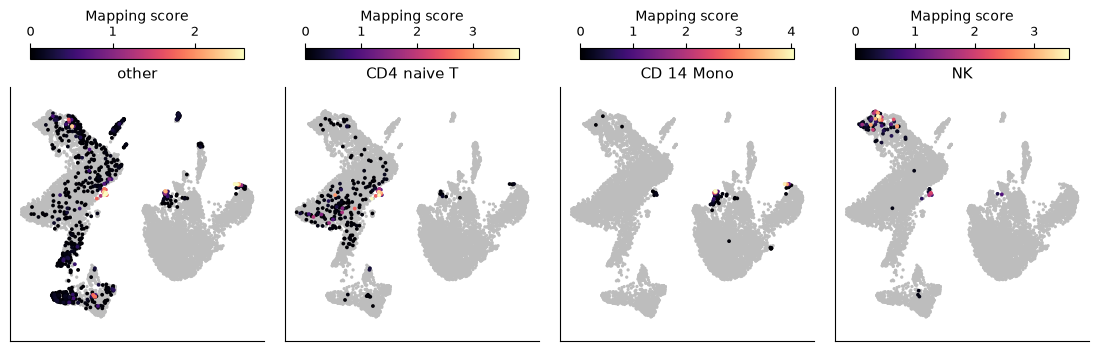

In [7]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
focus = {"CD 14 Mono", "CD4 naive T", "NK"}
score_groups = np.array(
    [label if label in focus else "other" for label in query_labels],
    dtype=object,
)
ds_stim.plots.mapping_score(
    mapping,
    layout_key="RNA_UMAP",
    target_groups=score_groups,
    figsize=(11, 3.4),
)

In [8]:
transferred_labels = ds_stim.get_target_classes(
    mapping,
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "transferred_labels",
    transferred_labels.to_numpy(),
    overwrite=True,
)
accepted = transferred_labels.notna() & transferred_labels.ne("NA")
accepted.value_counts().rename(
    index={True: "accepted", False: "abstained"}
).rename("query cells")

accepted     8376
abstained    1735
Name: query cells, dtype: int64

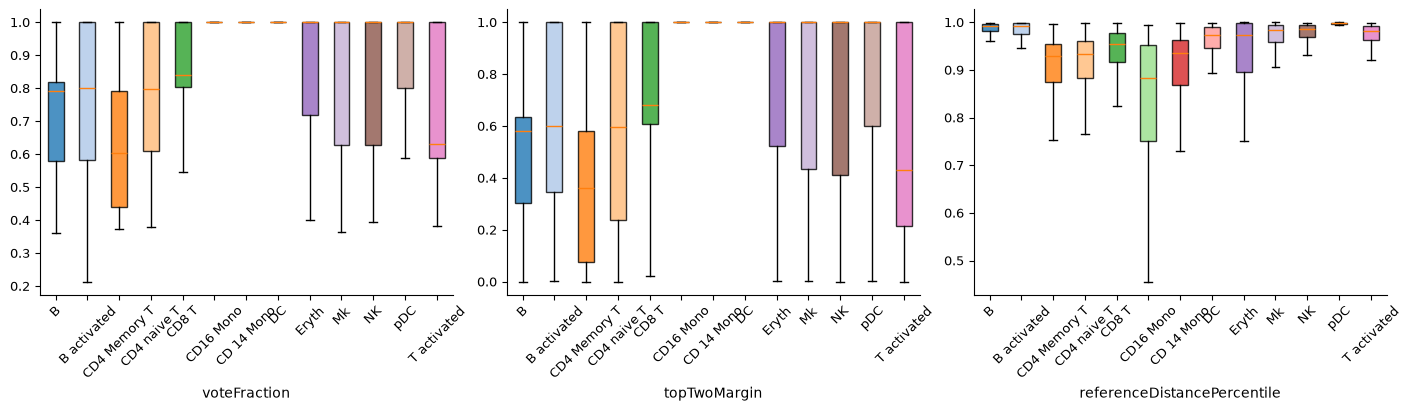

In [9]:
ds_stim.plots.mapping_evidence(
    mapping,
    reference_class_group="cluster_labels",
    target_groups=query_labels,
    metrics=("voteFraction", "topTwoMargin", "referenceDistancePercentile"),
    kind="box",
    threshold_fraction=0.6,
    figsize=(14, 4),
)

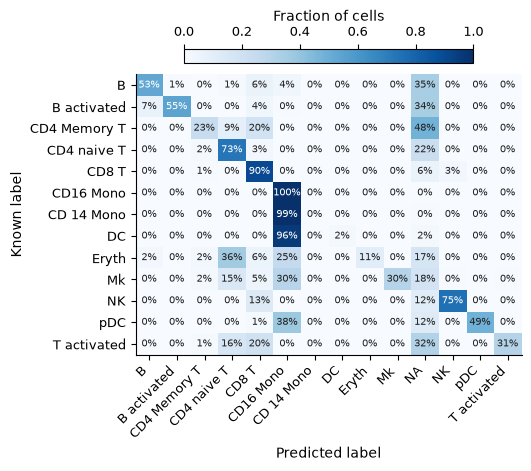

In [10]:
ds_stim.plots.mapping_confusion(
    mapping,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

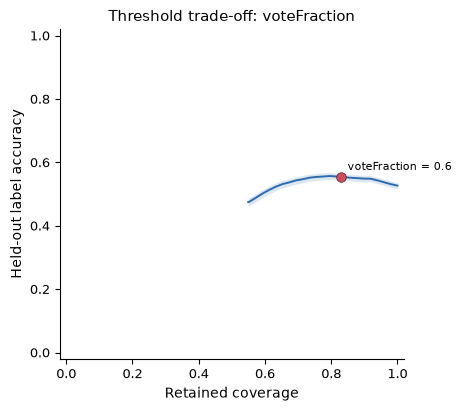

In [11]:
ds_stim.plots.mapping_calibration(
    mapping,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    metric="voteFraction",
    chosen_threshold=0.6,
)

In [12]:
projected_embedding = ds_stim.project_reference_embedding(
    mapping,
    reference_layout_key="RNA_UMAP",
    label="ref_UMAP",
)
projected_embedding

ArtifactRef(assay='RNA', kind='embedding', artifact_id='a0741397edeb...')

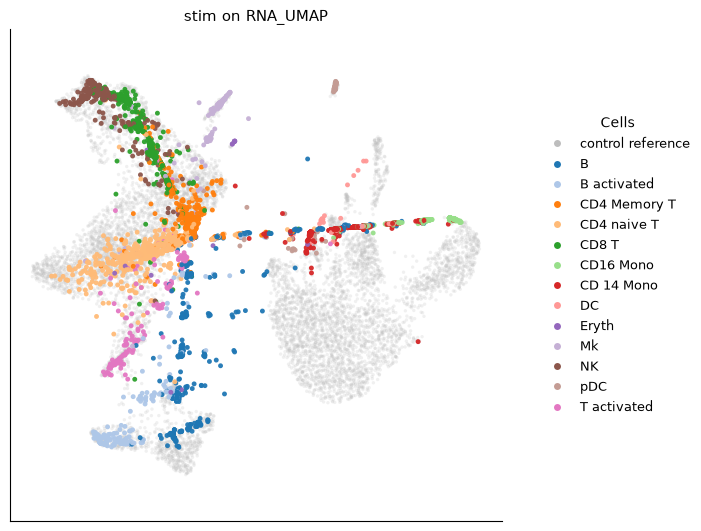

In [13]:
labelled_query = np.array(
    ["unlabelled" if label == "nan" else label for label in query_labels],
    dtype=object,
)
ds_stim.plots.mapping_projection(
    mapping,
    reference_layout_key="RNA_UMAP",
    target_groups=labelled_query,
    ref_name="control reference",
    reference_mode="background",
    figsize=(7.2, 5.2),
)

In [14]:
reference = ds_ctrl.get_mapping_reference(reference.ref)
reloaded_mapping = ds_stim.get_mapping_result(
    "stim",
    reference=reference,
    query_assay="RNA",
)
reloaded_mapping

MappingResult(ref=ArtifactRef(assay='RNA', kind='projection', artifact_id='a334aa5b4483...'), mapping_name='stim', n_cells=10111, correction_method='none', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1, 'algorithmVariant': 'scaled_pca', 'zeroNormCellCount': 0, 'queryScaledDispersion': 1.2273312252910447}, arrays=not loaded)